<a href="https://colab.research.google.com/github/samaaturky/nyc-taxi-fare-mlr/blob/main/nyc_taxi_fare_prediction_mlr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Taxi Fare Prediction — Multiple Linear Regression

## Overview
This project analyzes 2017 NYC Yellow Taxi trip data to identify the key factors
that drive fare amounts, and builds a multiple linear regression model to predict
`fare_amount` from trip characteristics.

## Dataset
- **Source:** NYC Taxi & Limousine Commission (TLC) 2017 Yellow Taxi trip records
- **Size:** ~22,700 trips, 17 original columns (pickup/dropoff time, location,
  distance, passenger count, fare components, payment type, etc.)

## Workflow
1. **Data cleaning** — handled invalid negative amounts, zero-distance trips,
   invalid categorical codes, and a data-logging bug producing ~24-hour trip
   durations
2. **Outlier treatment** — IQR-based capping on `trip_distance`, `duration`,
   and `fare_amount`
3. **Exploratory data analysis** — distribution plots, scatter plots, and a
   correlation matrix to identify relationships between trip features and fare
4. **Statistical testing** — correlation significance test and a t-test
   comparing fares across payment types
5. **Model building** — multiple linear regression using `trip_distance`,
   `duration`, `passenger_count`, and one-hot encoded categorical predictors
   (`VendorID`, `RatecodeID`, `payment_type`)
6. **Model evaluation** — R², MAE, RMSE on a held-out test set
7. **Assumption checks** — linearity, homoscedasticity, normality of residuals,
   and multicollinearity (VIF)

## Key Results
- R² ≈ 0.96, MAE ≈ $0.60 — `trip_distance` and `duration` are by far the
  strongest predictors of fare
- No meaningful multicollinearity (all VIF < 5)
- Mild violations of homoscedasticity/normality, mainly driven by the outlier
  capping step — noted as a limitation

## Tools
`pandas`, `numpy`, `scipy`, `seaborn`, `matplotlib`, `scikit-learn`, `statsmodels`

In [30]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("2017_Yellow_Taxi_Trip_Data (1).csv", index_col = 0)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.00,0.3,16.56
35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.00,0.3,20.80
106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.00,0.3,8.75
38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.00,0.3,27.69
30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.00,0.3,17.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14873857,2,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,3,0.61,1,N,48,186,2,4.0,1.0,0.5,0.00,0.00,0.3,5.80
66632549,2,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,1,16.71,2,N,132,164,1,52.0,0.0,0.5,14.64,5.76,0.3,73.20
74239933,2,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,1,0.42,1,N,107,234,2,4.5,0.0,0.5,0.00,0.00,0.3,5.30
60217333,2,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,1,2.36,1,N,68,144,1,10.5,0.0,0.5,1.70,0.00,0.3,13.00


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22699 entries, 24870114 to 17208911
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               22699 non-null  int64  
 1   tpep_pickup_datetime   22699 non-null  object 
 2   tpep_dropoff_datetime  22699 non-null  object 
 3   passenger_count        22699 non-null  int64  
 4   trip_distance          22699 non-null  float64
 5   RatecodeID             22699 non-null  int64  
 6   store_and_fwd_flag     22699 non-null  object 
 7   PULocationID           22699 non-null  int64  
 8   DOLocationID           22699 non-null  int64  
 9   payment_type           22699 non-null  int64  
 10  fare_amount            22699 non-null  float64
 11  extra                  22699 non-null  float64
 12  mta_tax                22699 non-null  float64
 13  tip_amount             22699 non-null  float64
 14  tolls_amount           22699 non-null  float64
 1

In [33]:
df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


* There are some negative values in fare_amount, extra, mta_tax , improvement_surcharge, and total_amount which should be >=0 so it must be fixed

In [34]:
# checking how many negative values to decide the best solution:
print((df['fare_amount'] < 0).sum())
print((df['total_amount'] < 0).sum())
print((df['extra'] < 0).sum())
print((df['improvement_surcharge'] < 0).sum())
print((df['mta_tax'] < 0).sum())

14
14
9
14
13


In [35]:
# Check the actual overlap:
neg_rows = df[(df['fare_amount'] < 0) | (df['total_amount'] < 0) |
              (df['extra'] < 0) | (df['improvement_surcharge'] < 0) |
              (df['mta_tax'] < 0)]
print(len(neg_rows))
neg_rows[['fare_amount','extra','mta_tax','tip_amount','tolls_amount','improvement_surcharge','total_amount']]

14


,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
105454287,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
57337183,-2.5,0.0,-0.5,0.0,0.0,-0.3,-3.3
97329905,-3.0,-0.5,-0.5,0.0,0.0,-0.3,-4.3
28459983,-3.5,0.0,-0.5,0.0,0.0,-0.3,-4.3
833948,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
91187947,-3.5,-0.5,-0.5,0.0,0.0,-0.3,-4.8
55302347,-2.5,-1.0,-0.5,0.0,0.0,-0.3,-4.3
58395501,-4.5,0.0,-0.5,0.0,0.0,-0.3,-5.3
29059760,-120.0,0.0,0.0,0.0,0.0,-0.3,-120.3
109276092,-4.0,-0.5,-0.5,0.0,0.0,-0.3,-5.3


* That confirms it — the union is 14, same as the individual counts for fare_amount, total_amount, and improvement_surcharge. So these aren't scattered data errors — it's one clean, coherent set of 14 rows where the entire transaction got reversed (refund/cancellation), and extra/mta_tax just happen to already be 0 or near-0 for some of those same rows rather than negative.

* 14 rows (0.06% of the dataset) represent refunded/reversed trips and can be dropped as a single block without needing separate rules per column.

In [36]:
df = df[df['total_amount'] >= 0].reset_index(drop=True)
print(df.shape)

(22685, 17)


In [37]:
df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000,22685.000000
mean,1.555962,1.642231,2.914952,1.043244,162.421732,161.544545,1.335552,13.041876,0.333723,0.498038,1.836914,0.312734,0.299921,16.328490
std,0.496869,1.285034,3.653698,0.708122,66.632736,70.136002,0.493288,13.212569,0.462812,0.031257,2.801119,1.399622,0.004878,16.068902
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,2.000000,2.000000,3.070000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


* fixed: now there is no negative values

In [38]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
# Derive trip duration
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])
# calculating duration of the trip using pickup and dropoff time in mins
df['duration']=(df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60
df['duration']

,duration
0,14.066667
1,26.500000
2,7.200000
3,30.250000
4,16.716667
...,...
22680,3.266667
22681,40.800000
22682,4.133333
22683,11.933333


In [43]:
# checking the valid values in the already encoded data:
for col in ['passenger_count', 'RatecodeID', 'payment_type', 'VendorID']:
    print(df[col].value_counts())

passenger_count
1    16107
2     3303
5     1142
3      953
6      692
4      455
0       33
Name: count, dtype: int64
RatecodeID
1     22057
2       513
5        67
3        39
4         8
99        1
Name: count, dtype: int64
payment_type
1    15265
2     7267
3      114
4       39
Name: count, dtype: int64
VendorID
2    12612
1    10073
Name: count, dtype: int64


* 33 passenger_count=0 which is invalid and 1 RatecodeID=99 which is negligible so drop them




In [44]:
df = df[(df['passenger_count'] != 0) & (df['RatecodeID'] != 99)].reset_index(drop=True)
print(df.shape)  # should be 22699 - 14 (negatives) - 33 (zero passengers) - 1 (ratecode 99) = 22651

(22652, 18)


In [46]:
# Check trip_distance == 0 and duration validity:
print((df['trip_distance'] == 0).sum())
print((df['duration'] <= 0).sum())

146
26


In [49]:
df['duration'].describe()

,duration
count,22652.000000
mean,16.965982
std,61.378799
min,-16.983333
25%,6.666667
50%,11.183333
75%,18.383333
max,1439.550000


In [50]:
df[df['trip_distance'] == 0][['fare_amount','duration']].describe()

,fare_amount,duration
count,146.000000,146.000000
mean,22.935959,1.104452
std,47.403462,3.847309
min,0.000000,0.000000
25%,2.500000,0.050000
50%,3.000000,0.150000
75%,29.875000,0.487500
max,450.000000,32.116667


In [51]:
# Drop rows with impossible values — these aren't outliers, they're errors
df = df[(df['trip_distance'] > 0) & (df['duration'] > 0)].reset_index(drop=True)
print(df.shape)

# Check how many trips are unreasonably long (data errors vs. legit long trips)
print((df['duration'] > 180).sum())  # over 3 hours
df.nlargest(10, 'duration')[['trip_distance','fare_amount','duration']]

(22505, 18)
45


,trip_distance,fare_amount,duration
912,4.86,17.5,1439.550000
15441,0.74,7.0,1439.150000
14863,0.95,8.0,1438.850000
22445,1.73,9.0,1438.650000
15027,1.99,7.0,1438.550000
7864,1.09,7.0,1438.466667
21185,3.13,29.5,1438.266667
6686,2.93,18.5,1438.033333
6429,15.60,52.0,1437.833333
18492,4.70,23.5,1436.966667


Text(0.5, 1.0, 'Duration outliers (before cleaning)')

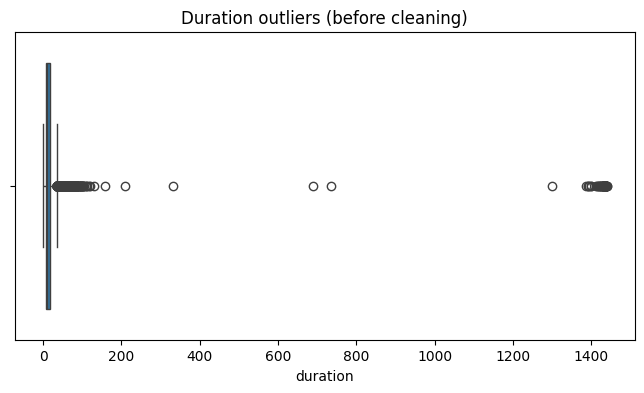

In [52]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['duration'])
plt.title('Duration outliers (before cleaning)')

1. The main box is tiny and sits near 0 — the IQR (box width) is compressed against the left edge because the bulk of your data is in the 5–20 minute range, while a handful of extreme values stretch the x-axis out to 1400+. This is the "std is 3.6x the mean" problem showing up visually — a few outliers are distorting the whole scale, making the real distribution (where 75% of your data lives) look like a sliver.

2. Clear separation into two clusters of extreme values:

A middling group scattered between ~150–800 minutes (the circles at 150, 200, 330, 700, 750) — these are individually flagged as outliers, but they're spread out, not clustered. That pattern is consistent with genuinely long trips (heavy traffic, long-haul rides) — plausible real data.
The tight cluster right at ~1400–1440 — this is the group we already identified via the table. Visually, you can see they're bunched together almost as a solid block, unlike the scattered middle group. That tight clustering is the visual fingerprint of a systematic bug, not natural variation.

This is a nice confirmation of the two-tier decision:

The scattered mid-range outliers (150–800 min) → legitimate extreme values, good candidates for IQR capping (pull them down to the upper fence rather than deleting)
The tight cluster near 1440 → still recommend dropping, since clustering that dense at almost exactly 24 hours isn't something natural trip variation produces

Text(0.5, 1.0, 'Duration outliers (after removing >180 min)')

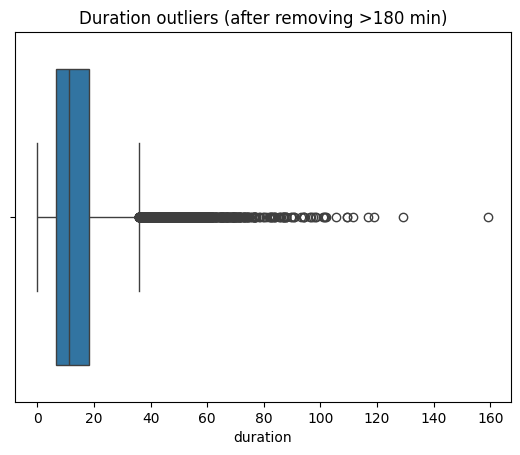

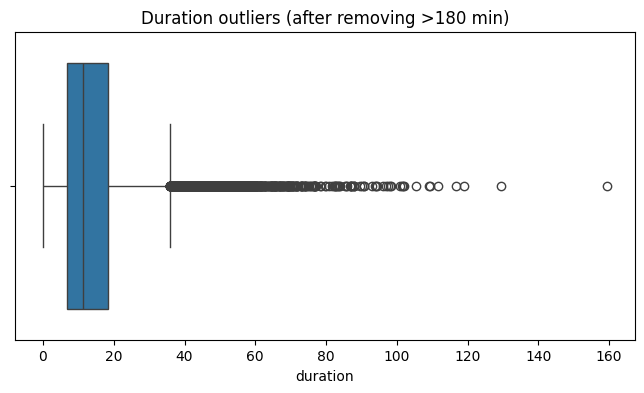

In [54]:
# re-plot after your duration <= 180
sns.boxplot(x=df[df['duration'] <= 180]['duration'])
plt.title('Duration outliers (after removing >180 min)')
plt.figure(figsize=(8,4))
sns.boxplot(x=df[df['duration'] <= 180]['duration'])
plt.title('Duration outliers (after removing >180 min)')

* the outlier tail is now smooth and gradually thinning, not clustered

In [55]:
# IQR:pull anything above the upper whisker down to that fence value, rather than deleting rows. This reduces leverage from the extreme points without losing sample size or falsely treating legitimate long trips as errors.
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = max(Q1 - 1.5 * IQR, 0)

df['duration'] = df['duration'].clip(lower=lower_fence, upper=upper_fence)

Text(0.5, 1.0, 'fare_amount after')

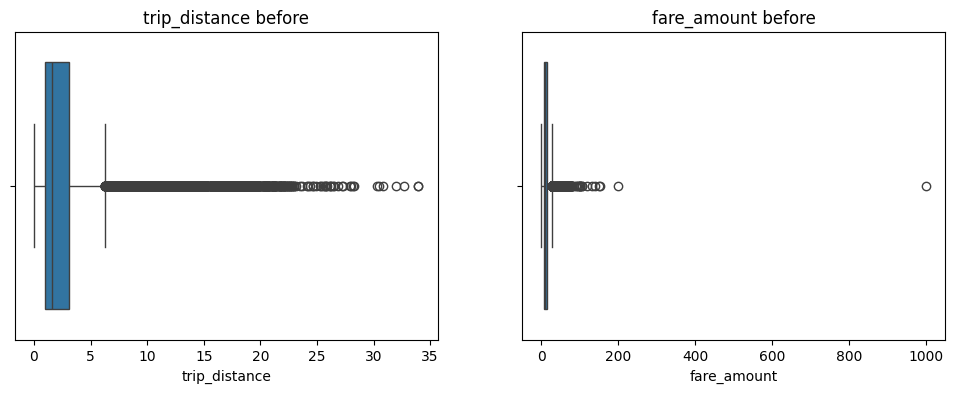

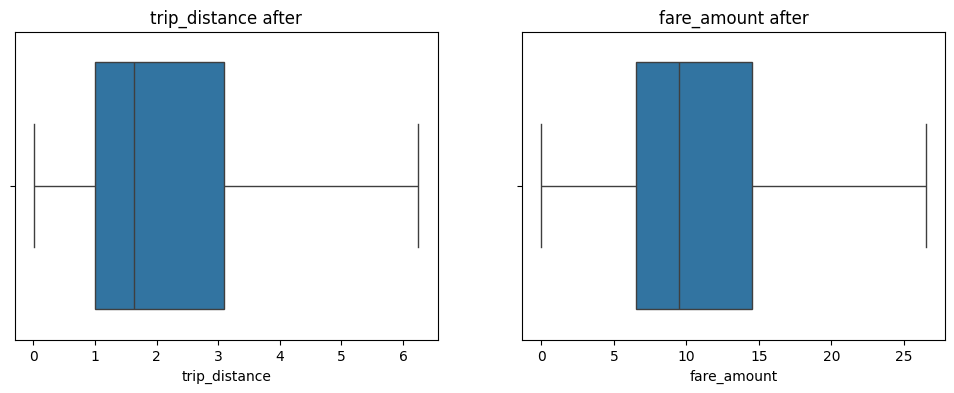

In [56]:
# reusable capping function — same IQR logic used for duration
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = max(Q1 - 1.5 * IQR, 0)  # can't go below 0 for distance/fare
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# before plots — same before/after pattern as duration
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=df['trip_distance'], ax=axes[0]); axes[0].set_title('trip_distance before')
sns.boxplot(x=df['fare_amount'], ax=axes[1]); axes[1].set_title('fare_amount before')

# apply capping
df = cap_outliers(df, 'trip_distance')
df = cap_outliers(df, 'fare_amount')

# after plots — confirm the fix visually
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=df['trip_distance'], ax=axes[0]); axes[0].set_title('trip_distance after')
sns.boxplot(x=df['fare_amount'], ax=axes[1]); axes[1].set_title('fare_amount after')

# EDA Visualization:

<Axes: title={'center': 'RatecodeID counts'}, xlabel='RatecodeID'>

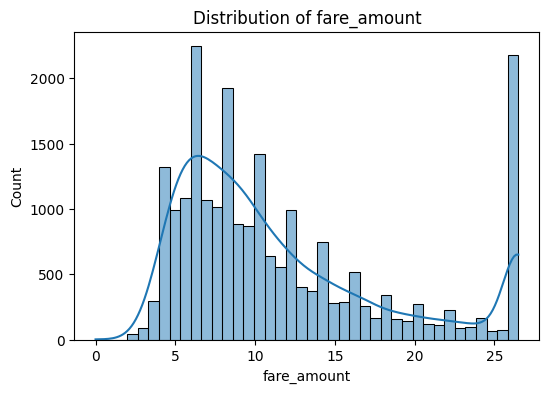

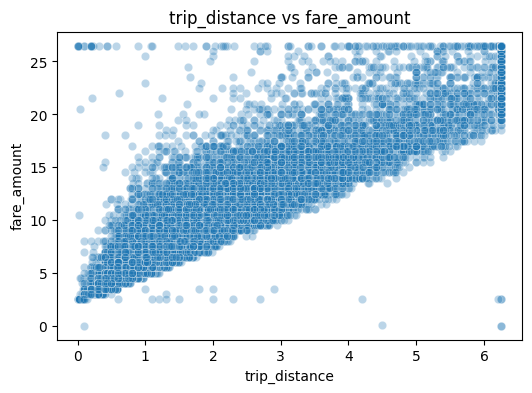

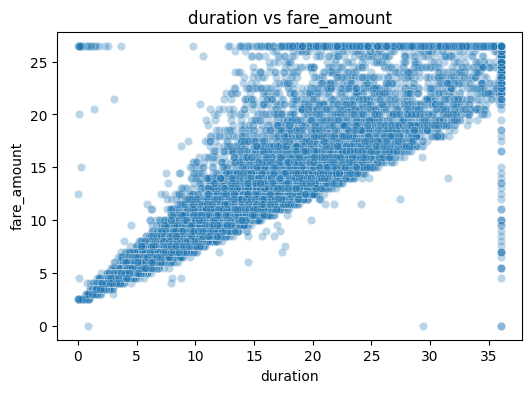

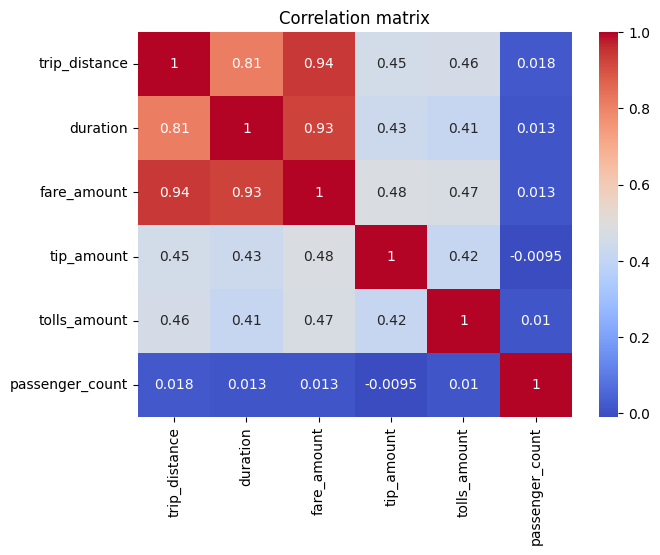

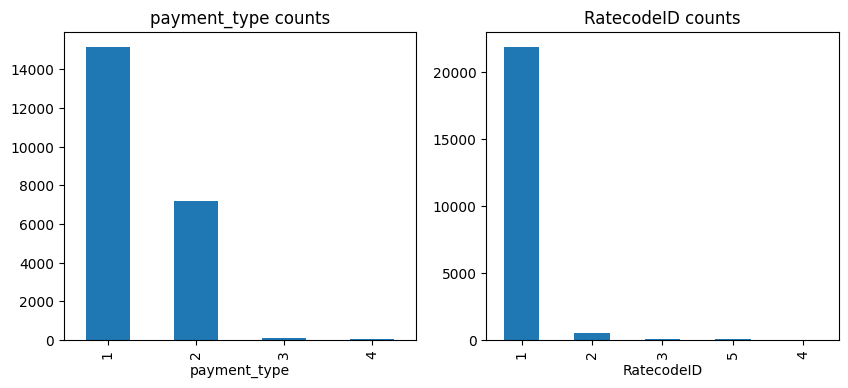

In [57]:
# distribution of the target variable
plt.figure(figsize=(6,4))
sns.histplot(df['fare_amount'], bins=40, kde=True)
plt.title('Distribution of fare_amount')

# the core relationship you're modeling: does distance predict fare?
plt.figure(figsize=(6,4))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df, alpha=0.3)
plt.title('trip_distance vs fare_amount')

# does trip duration also predict fare?
plt.figure(figsize=(6,4))
sns.scatterplot(x='duration', y='fare_amount', data=df, alpha=0.3)
plt.title('duration vs fare_amount')

# correlation heatmap across numeric predictors
num_cols = ['trip_distance','duration','fare_amount','tip_amount','tolls_amount','passenger_count']
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')

# categorical breakdowns — counts of payment type and rate code
fig, axes = plt.subplots(1,2, figsize=(10,4))
df['payment_type'].value_counts().plot(kind='bar', ax=axes[0], title='payment_type counts')
df['RatecodeID'].value_counts().plot(kind='bar', ax=axes[1], title='RatecodeID counts')

## EDA Insights

**Fare Distribution**
- The `fare_amount` distribution is right-skewed with a visible spike near $26 — this is an artifact of the IQR outlier capping applied earlier (all values above the upper fence were clipped to the same number), not a natural pattern in the data.

**Trip Distance & Duration vs. Fare**
- Both `trip_distance` and `duration` show a strong, clearly linear, positive relationship with `fare_amount`.
- Correlation with `fare_amount`: `trip_distance` = **0.94**, `duration` = **0.93** — these are the two strongest predictors.

**Multicollinearity Risk**
- `trip_distance` and `duration` are also correlated with each other (**0.81**). Since both are strongly related to the outcome and to each other, this is a multicollinearity risk to check (via VIF) before finalizing the model.

**Weaker Predictors**
- `tip_amount` (0.48) and `tolls_amount` (0.47) show moderate correlation with `fare_amount` — useful as secondary predictors, though `tip_amount` may

**Categorical Variables**
- `payment_type` is dominated by credit card (1) and cash (2); types 3 and 4 are negligible.
- `RatecodeID` is dominated by standard rate (1); codes 2–5 make up a small fraction of trips, and may need to be grouped into an "other" category before one-hot encoding to avoid unstable coefficients from too few observations.


In [58]:
# correlation significance test: is the trip_distance–fare_amount relationship
# statistically significant, not just visually apparent?
corr, p_value = stats.pearsonr(df['trip_distance'], df['fare_amount'])
print(f"correlation: {corr:.3f}, p-value: {p_value:.5f}")
# p < 0.05 confirms the relationship is statistically significant, not due to chance

# example hypothesis test: does fare differ by payment type (credit card vs cash)?
credit = df[df['payment_type'] == 1]['fare_amount']
cash   = df[df['payment_type'] == 2]['fare_amount']
t_stat, p_val = stats.ttest_ind(credit, cash, equal_var=False)
print(f"t-stat: {t_stat:.3f}, p-value: {p_val:.5f}")
# small p-value (<0.05) means the difference in mean fare between payment types is real

correlation: 0.942, p-value: 0.00000
t-stat: 9.226, p-value: 0.00000


## Statistical Testing

**Correlation Test (trip_distance vs. fare_amount)**
- Pearson correlation = **0.942**, p-value ≈ **0.00000**
- The p-value is far below 0.05, confirming the strong positive relationship between `trip_distance` and `fare_amount` is statistically significant and not due to random chance.

**T-Test (fare_amount by payment_type: credit card vs. cash)**
- t-statistic = **9.226**, p-value ≈ **0.00000**
- The p-value is far below 0.05, indicating a statistically significant difference in mean `fare_amount` between credit card and cash payments. This suggests `payment_type` may carry some information relevant to fare and is worth keeping as a predictor, though the practical size of the difference should also be checked (e.g., compare the actual mean fares for each group) before treating it as a meaningful business finding.

In [59]:
# pull useful time features from pickup timestamp
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['hour'] = df['tpep_pickup_datetime'].dt.hour

# one-hot encode categorical predictors — regression needs numeric dummy columns,
# not raw category codes like RatecodeID/payment_type/VendorID
df_model = pd.get_dummies(df, columns=['VendorID','RatecodeID','payment_type'], drop_first=True)

# Building the multiple linear regression model

In [61]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# choose predictors — start with the strongest candidates from your EDA/correlation step
features = ['trip_distance', 'duration', 'passenger_count'] + \
           [c for c in df_model.columns if c.startswith(('VendorID_','RatecodeID_','payment_type_'))]

X = df_model[features]
y = df_model['fare_amount']

# split into train/test so we can evaluate on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))  # sqrt of MSE instead of squared=False

# coefficients — how much each predictor moves fare_amount, holding others constant
coefs = pd.Series(model.coef_, index=features).sort_values()
print(coefs)

R²: 0.9619896642776736
MAE: 0.60144090639256
RMSE: 1.3271984343856584
payment_type_4    -0.780477
payment_type_3    -0.662710
VendorID_2        -0.089926
payment_type_2    -0.014107
passenger_count   -0.011433
duration           0.343295
RatecodeID_2       0.723948
RatecodeID_4       1.056003
trip_distance      2.041921
RatecodeID_3       2.123099
RatecodeID_5       2.925629
dtype: float64


## Model Performance & Coefficients

**Model Fit**
- R² = **0.962** — the model explains about 96% of the variance in `fare_amount`, indicating a strong fit.
- MAE = **$0.60** — on average, predictions are off by about 60 cents.
- RMSE = **$1.33** — slightly higher than MAE, meaning a few larger errors are pulling the average up (consistent with the fare-capping artifact noted earlier).

**Strongest Predictors**
- `trip_distance` (**+2.04**): each additional mile adds about $2.04 to the predicted fare, holding other variables constant — the single strongest continuous predictor, as expected from the EDA.
- `duration` (**+0.34**): each additional minute adds about $0.34 to fare. Smaller effect than distance, but still meaningful.

**RatecodeID Effects**
- Rate codes 2–5 (non-standard rates, e.g., JFK, negotiated fare) all show notably higher fares than the standard rate (code 1, the reference category): RatecodeID_5 (+2.93), RatecodeID_3 (+2.12), RatecodeID_4 (+1.06), RatecodeID_2 (+0.72). This makes sense — these rate types typically apply to longer or flat-fee trips (e.g., airport runs) that cost more than standard metered fares.

**Payment Type Effects**
- payment_type_3 (-0.66) and payment_type_4 (-0.78) are associated with notably lower fares compared to the reference category (credit card). Given these categories were shown to be very small groups in the EDA (negligible counts), these coefficients should be interpreted cautiously — they may be unstable due to low sample size rather than reflecting a reliable real-world effect.
- payment_type_2 (cash) shows a negligible effect (-0.014) — essentially no difference from credit card once other variables are controlled for.

**Weak/Negligible Predictors**
- `passenger_count` (-0.011) and `VendorID_2` (-0.09) have very small coefficients, confirming what the EDA correlation matrix already suggested — these variables add little explanatory power to the model.

## Next Steps
- Run a VIF check on `trip_distance` and `duration` to confirm whether their earlier-flagged correlation (0.81) is causing multicollinearity issues in the coefficient estimates.
- Interpret the `payment_type_3`/`payment_type_4` coefficients cautiously given their small sample sizes.
- Move to residual diagnostics (linearity, homoscedasticity, normality) to validate the regression assumptions before finalizing conclusions.

# Check regression assumptions

            feature       VIF
0     trip_distance  3.009626
1          duration  3.020555
2   passenger_count  1.078085
3        VendorID_2  1.085561
4      RatecodeID_2  1.125931
5      RatecodeID_3  1.009450
6      RatecodeID_4  1.002462
7      RatecodeID_5  1.007836
8    payment_type_2  1.007851
9    payment_type_3  1.010274
10   payment_type_4  1.003427


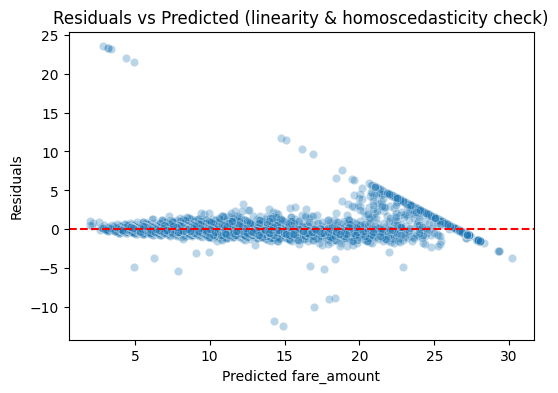

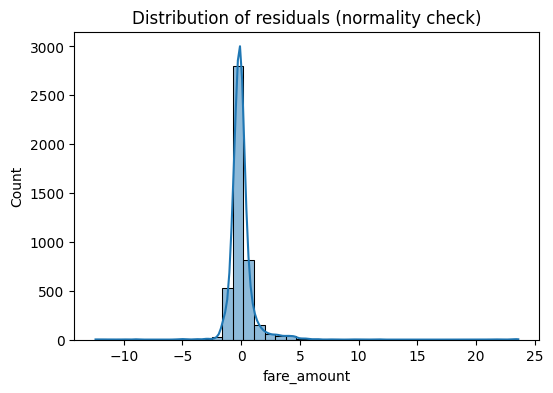

In [62]:
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

residuals = y_test - y_pred

# 1. Linearity — residuals vs predicted, should show no pattern
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted fare_amount'); plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (linearity & homoscedasticity check)')

# 2. Normality of residuals — should look roughly bell-shaped
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title('Distribution of residuals (normality check)')

# 3. Multicollinearity — VIF > 5-10 signals a problem predictor
vif_data = pd.DataFrame()
vif_data['feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data)

- Model assumptions are reasonably well met: linearity holds, multicollinearity is not a concern (VIF confirms this despite the earlier correlation flag), but homoscedasticity and normality show mild violations driven mainly by the outlier-capping step applied during cleaning.
- Recommended caveat: results and R² should be interpreted with the understanding that capped fares slightly compress the model's apparent accuracy at the high end; a future iteration could compare capping vs. transformation (e.g., log fare) to assess whether it improves residual behavior.